# Gaia Be Star → Roman Time Sampling Pipeline

This notebook demonstrates the end-to-end pipeline for predicting what a **Be star outburst** observed by Gaia (G-band) would look like on the **Nancy Grace Roman Space Telescope** cadence.

In [522]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from astropy.io import fits
from astropy.table import Table
import george
from george import kernels
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import FancyArrowPatch
from functions import (
    read_fits, prep_input, prep_gp, fit_gp,
    binning_data, multiscale_peaks, predict_gp,
    get_metrics, l2_distance, find_valid_rows
)
from gp_model_params import info
from tqdm.notebook import tqdm
np.random.seed(42)

In [523]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 13,
    "axes.labelsize"   : 14,
    "axes.titlesize"   : 14,
    "legend.fontsize"  : 11,
    "xtick.direction"  : "in",
    "ytick.direction"  : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"       : 120,
})

# Colour palette (colour-blind friendly)
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [524]:
# Paths and source-type configuration
home = str(Path.home())

TP   = 'Be'
BAND = 'G'        # Gaia G-band

DATA_PATH   = home + '/Research_data/GAIA BE stars/Gaia_Be_stars_candidates/gaia_science_alerts_be_stars_lightcurves/'
OUTPUT_PLOT = f'output/plots/{TP}/'
OUTPUT_FILE = 'output/'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)

# Be stars are non-periodic — period is set to NaN throughout
period = np.nan

## Load Roman Telescope Cadence Arrays

In [525]:
# Load pre-computed Roman Galactic Bulge cadence time arrays
Roman_sampling_short  = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long   = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2  = np.load('lc_example/roman_times_longcadence2.npy')


Roman_sampling_long   -= Roman_sampling_long.min()
Roman_sampling_long2  -= Roman_sampling_short.min()
Roman_sampling_short  -= Roman_sampling_short.min()

Roman_max_short_time = Roman_sampling_short.max()

t_base       = Roman_sampling_short
t_base_long  = Roman_sampling_long
t_base_long2 = Roman_sampling_long2

# Dense regular grid for smooth curve evaluation
t_regular = np.linspace(0, Roman_max_short_time, 750_000)

print(f"Short cadence  : {len(t_base):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence 1 : {len(t_base_long):,} pts  |  span = {t_base_long.max():.1f} d")
print(f"Long cadence 2 : {len(t_base_long2):,} pts  |  span = {t_base_long2.max():.1f} d")

Short cadence  : 50,700 pts  |  span = 982.0 d
Long cadence 1 : 1,704 pts  |  span = 981.8 d
Long cadence 2 : 1,704 pts  |  span = 981.9 d


## Load a Single Gaia Be Star Light Curve

Gaia Science Alerts provides G-band photometry for transient events including Be star outbursts. Each source is stored as a CSV with columns `JD(TCB)`, `mag`, and `err`.

In [660]:
# Discover all available light curve CSVs
lc_list = sorted(glob(DATA_PATH + '*.csv'))
print(f"Found {len(lc_list)} light curve files.")

# Select a single demo source
demo_path = DATA_PATH+'Gaia23cne.csv' #lc_list[17]
demo_id   = Path(demo_path).stem
print(f"Demo source   : {demo_id}")

Found 270 light curve files.
Demo source   : Gaia23cne


In [661]:
# Read CSV and rename columns to pipeline convention
loaded_df = pd.read_csv(demo_path).reset_index(drop=True)
df        = loaded_df.rename(columns={"JD(TCB)": "t", "mag": "m", "err": "e"})

print(f"G-band : {len(df):,} points  "
      f"| t ∈ [{df.t.min():.1f}, {df.t.max():.1f}] JD days  "
      f"| <m> = {df.m.mean():.3f}")
df.head()

G-band : 68 points  | t ∈ [2457078.3, 2460206.5] JD days  | <m> = 14.027


,t,m,e
0,2.457078e+06,14.04,0.004055
1,2.457078e+06,14.02,0.004018
2,2.457103e+06,14.09,0.004150
3,2.457103e+06,14.04,0.004055
4,2.457130e+06,14.03,0.004036


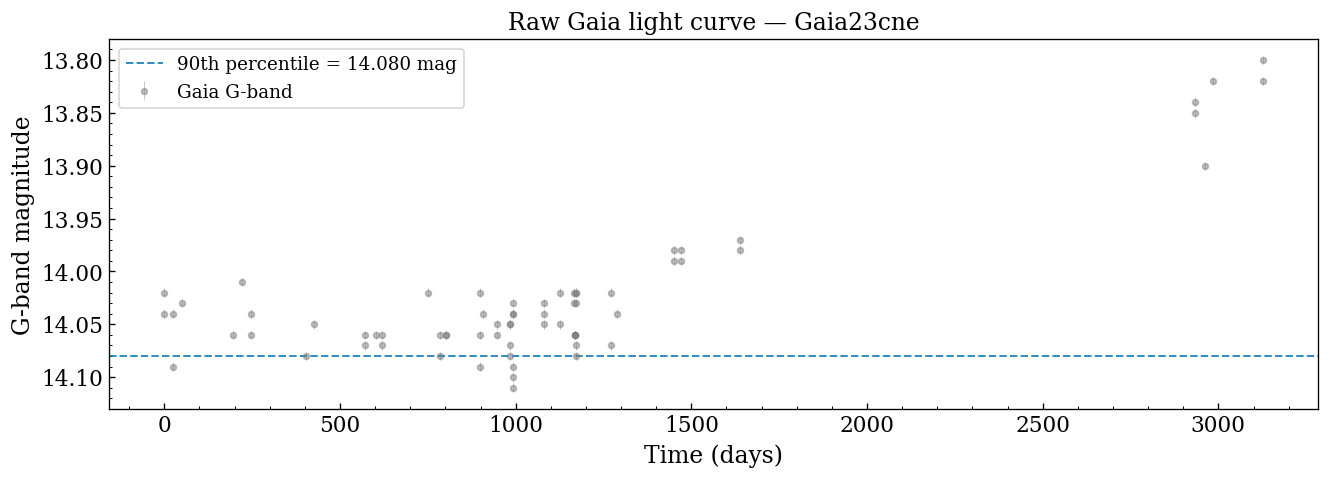

In [662]:
# Raw Gaia G-band light curve

fig, ax = plt.subplots(figsize=(13, 4))

ax.errorbar(df.t-np.min(df.t), df.m, yerr=df.e, fmt='.', color='grey',
            alpha=0.5, ms=7, lw=0.5, label='Gaia G-band', zorder=2)
ax.axhline(np.percentile(df.m, 90), color=C0, lw=1.2, ls='--',
           alpha=0.8, label=f'90th percentile = {np.percentile(df.m, 90):.3f} mag')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G-band magnitude')
ax.set_title(f'Raw Gaia light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## Preprocessing

In [663]:
# Normalise time axis
if df.t.min() > 0:
    df['t'] = df['t'] - df['t'].min()

In [691]:
# Compress observing gaps > 500 days

inds  = np.where(np.diff(df.t.values) > 500)[0]
t_min = np.min(np.diff(df.t.values))

df_modified = df.copy()
for ind in inds:
    time_gap = df_modified.t.iloc[ind + 1] - df_modified.t.iloc[ind] + t_min
    df_modified.loc[df_modified.index[ind + 1]:, 't'] -= time_gap

print(f"Gaps compressed : {len(inds)} gap(s) removed")
print(f"Baseline span   : {df.t.max():.1f} d  →  {df_modified.t.max():.1f} d")

Gaps compressed : 1 gap(s) removed
Baseline span   : 3128.2 d  →  1833.1 d


In [692]:
# Rescale time axis by scale factor so the scaled time axis be between 0 and 5

df_modified = df_modified.copy()
scale_factor = np.max(df_modified['t'])/5
df_modified['t'] = df_modified['t']/scale_factor

print(f"Time axis after rescaling: [{df_modified.t.min():.4f}, {df_modified.t.max():.4f}]  (× {scale_factor:.2f} = days)")

Time axis after rescaling: [0.0000, 5.0000]  (× 366.62 = days)


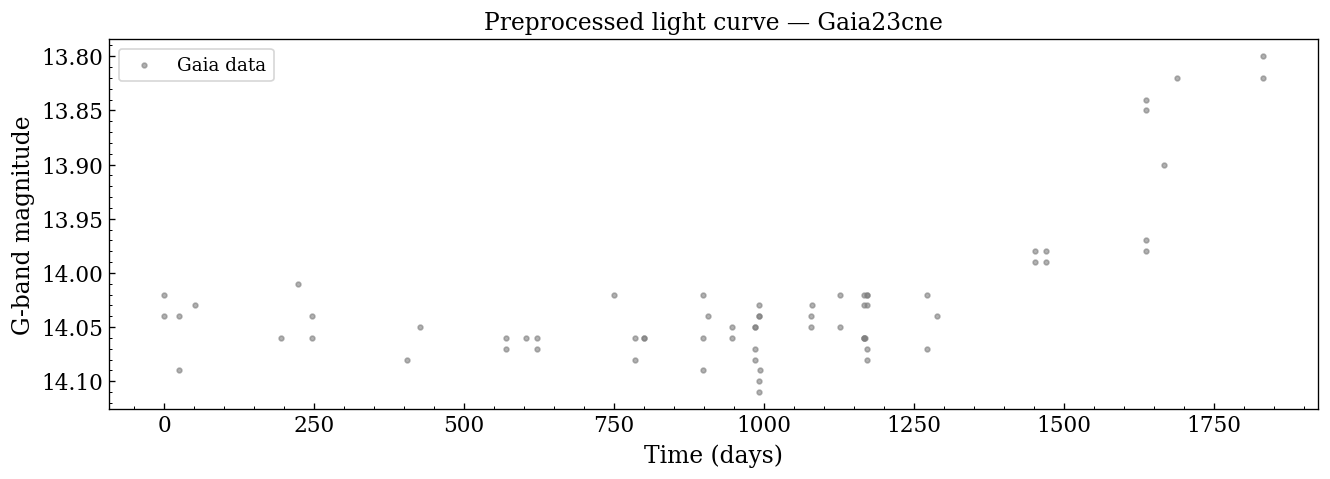

In [693]:
# Preprocessed light curve
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(df_modified.t * scale_factor, df_modified.m, s=8, alpha=0.6,
           color='grey', label='Gaia data')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G-band magnitude')
ax.set_title(f'Preprocessed light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## GP Preparation and Binning

In [694]:
len(df_modified)

68

In [695]:
# Initialise GP and build multi-phase input array

info[TP]['gp_opt_s_param'] = 0

gp = prep_gp(info[TP], period)

x, y, e = prep_input(df_modified, TP, period, info[TP], Roman_max_short_time)

In [696]:
# Bin the data to reduce GP matrix size

if len(x) > 130:
    info[TP]['fit_binned'] = True
    x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
        x, y, e, info[TP], n_bins=100
    )
else:
    info[TP]['fit_binned'] = False
    x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
        x, y, e, info[TP], n_bins=np.nan
    )

# Drop bins whose error estimate is NaN (empty bins at the edges)
valid    = ~np.isnan(e_binned)
x_binned = x_binned[valid]
y_binned = y_binned[valid]
e_binned = e_binned[valid]

y_median = np.percentile(y, 90)   # use 90th-percentile as baseline (faintest typical flux)

print(f"Binned size : {len(x_binned)} points  (from {len(x)} raw)")
print(f"y_median    : {y_median:.4f} mag")

Binned size : 68 points  (from 68 raw)
y_median    : 14.0800 mag


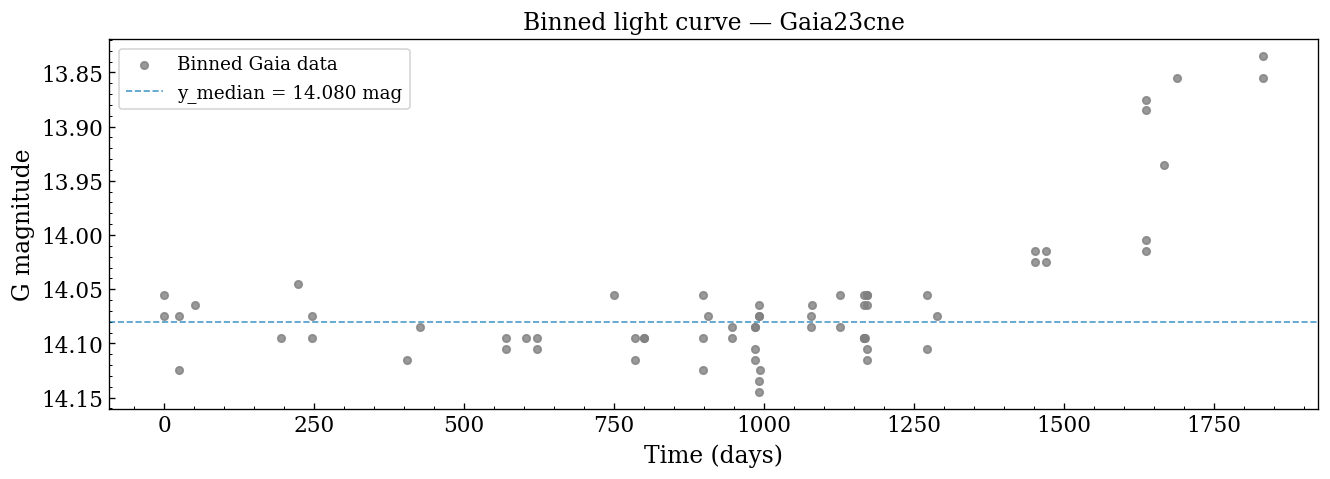

In [697]:
# Binned light curve
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(x_binned * scale_factor, y_binned + y_median, s=20, alpha=0.8,
           color='grey', zorder=3, label='Binned Gaia data')
ax.axhline(y_median, color=C0, lw=1.0, ls='--', alpha=0.7,
           label=f'y_median = {y_median:.3f} mag')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G magnitude')
ax.set_title(f'Binned light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## GP Fitting

In [698]:
# Fit GP to the binned data
import time
info[TP]['gp_opt_s_param'] = 4.5
t0 = time.time()
gp = fit_gp(x_binned, y_binned, e_binned, info[TP], gp)
print(f"GP fit complete in {time.time() - t0:.1f} s")
print(f"Kernel params  : {gp.kernel.parameter_vector}")

GP fit complete in 0.1 s
Kernel params  : [2.99999692 2.00000074]


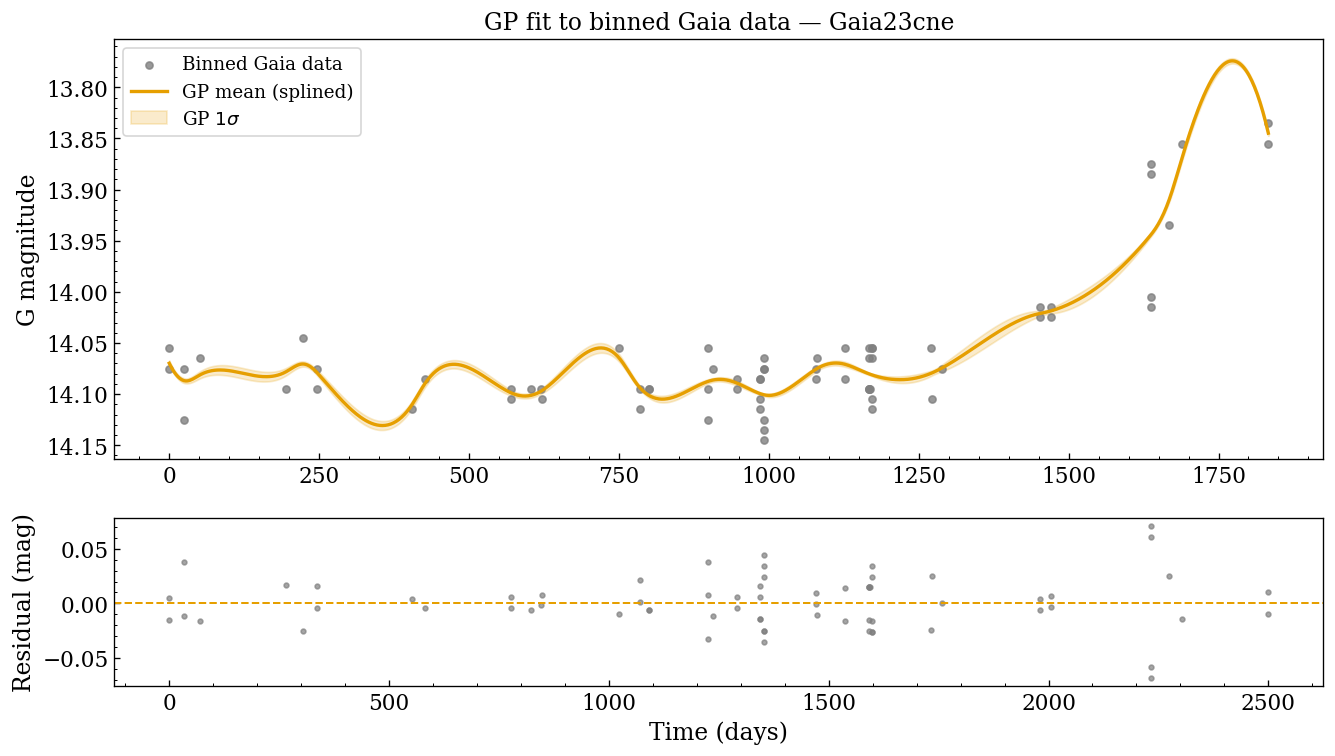

In [699]:
# GP mean evaluated at binned data points

from scipy.interpolate import CubicSpline

gp_y_binned_fit, cov_binned = gp.predict(y_binned, x_binned, return_cov=True)
gp_std_binned               = np.sqrt(np.diag(cov_binned))

# Build smooth display curve via spline (avoids dense-grid GP ringing)
sort_idx      = np.argsort(x_binned)
cs_fit        = CubicSpline(x_binned[sort_idx], gp_y_binned_fit[sort_idx])
cs_std        = CubicSpline(x_binned[sort_idx], gp_std_binned[sort_idx])
x_display     = np.linspace(x_binned.min(), x_binned.max(), 800)
y_display     = cs_fit(x_display)
std_display   = np.abs(cs_std(x_display))


fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
ax.scatter(x_binned * scale_factor, y_binned + y_median,
           s=18, alpha=0.8, color='grey', zorder=3, label='Binned Gaia data')
ax.plot(x_display * scale_factor, y_display + y_median,
        color=C1, lw=2.0, zorder=4, label='GP mean (splined)')
ax.fill_between(x_display * scale_factor,
                y_display + y_median - std_display,
                y_display + y_median + std_display,
                color=C1, alpha=0.2, label=r'GP $1\sigma$')
ax.invert_yaxis()
ax.set_ylabel('G magnitude')
ax.set_title(f'GP fit to binned Gaia data — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Residuals
resid = y_binned - gp_y_binned_fit
axes[1].scatter(x_binned * 500, resid, s=8, alpha=0.7, color='grey')
axes[1].axhline(0, color=C1, lw=1.2, ls='--')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Residual (mag)')
axes[1].xaxis.set_minor_locator(AutoMinorLocator())


In [700]:
np.sum((gp_y_binned_fit-y_binned)**2)

np.float64(0.03899051017676994)

## Roman Resampling via Random Injection of the Be outburst

Outburst lc starts at t = 783 days
0.32975884562375485
Outburst lc starts at t = 761 days
0.3164065310503943


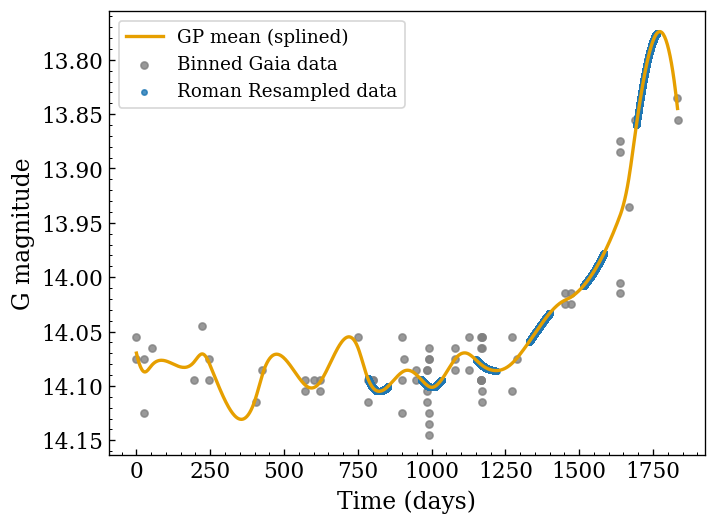

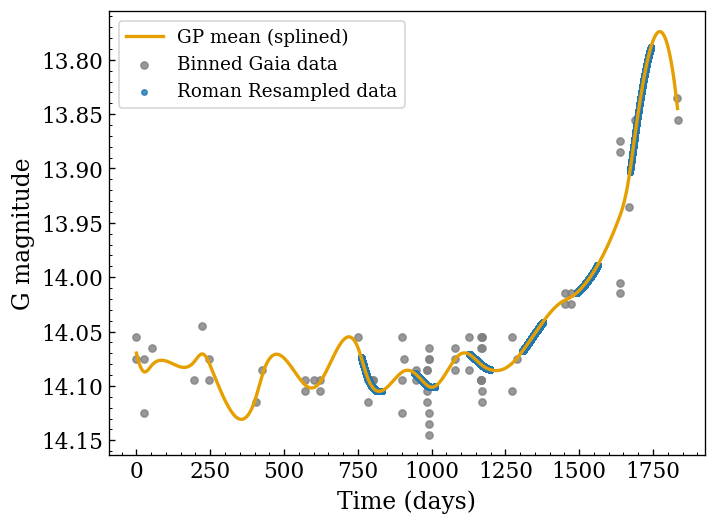

In [702]:
n_lc = 2
baseline_mag = max(y_binned + y_median)


counter = 0
for i in range(n_lc):

    


    
    y_sim_long = y_base_long.copy()
    y_sim_long2 = y_base_long2.copy()
    y_sim_regular = y_base_regular.copy()

    
    counter += 1

    ptp_init = 0

    while ptp_init<0.1:

        t_s = np.random.choice(t_base_exc_edge, size=1)[0]
        y_sim = y_base.copy()
        t_local = t_base + t_s
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim = outburst_mag
        ptp_init = np.ptp(y_sim)
        

    plt.figure()
    print(f"Outburst lc starts at t = {t_s:.0f} days")
    
    plt.plot(x_display * scale_factor, y_display+y_median,
            color=C1, lw=2.0, zorder=4, label='GP mean (splined)')
    plt.scatter(x_binned * scale_factor, y_binned+y_median,
               s=18, alpha=0.8, color='grey', zorder=3, label='Binned Gaia data')
    plt.scatter(t_base + t_s, y_sim + y_median,
                s=10, alpha=0.8, color='C0', zorder=3, label='Roman Resampled data')
    # plt.axvline(t_rise)
    # plt.axvline(t_min)
    # plt.axvline(t_max)

    ax = plt.gca()
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('G magnitude')
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    print(np.ptp(y_sim))



## GP Fit parameter optimization

In [482]:
all_s_params = [0, 1, 1.1, 1.3, 1.5]

stats = np.zeros((len(all_s_params), len(lc_list)))
names = []
for s, s_param in enumerate(all_s_params):
    info[TP]['gp_opt_s_param'] = s_param
    for i, path_lc in tqdm(enumerate(lc_list)):
        if s_param==1:
            names.append(Path(path_lc).stem)
        loaded_df = pd.read_csv(path_lc).reset_index(drop=True)
        df        = loaded_df.rename(columns={"JD(TCB)": "t", "mag": "m", "err": "e"})
    
        # Normalise time axis
        if df.t.min() > 0:
            df['t'] = df['t'] - df['t'].min()
        
        # Compress observing gaps > 500 days
        
        inds  = np.where(np.diff(df.t.values) > 500)[0]
        t_min = np.min(np.diff(df.t.values))
        
        df_modified = df.copy()
        for ind in inds:
            time_gap = df_modified.t.iloc[ind + 1] - df_modified.t.iloc[ind] + t_min
            df_modified.loc[df_modified.index[ind + 1]:, 't'] -= time_gap
        
        
        # Rescale time axis by scale factor so the scaled time axis be between 0 and 5
        
        df_modified = df_modified.copy()
        scale_factor = np.max(df_modified['t'])/5
        df_modified['t'] = df_modified['t']/scale_factor
            # Initialise GP and build multi-phase input array
        
        
        
        gp = prep_gp(info[TP], period)
        
        x, y, e = prep_input(df_modified, TP, period, info[TP], Roman_max_short_time)
        
        # Bin the data to reduce GP matrix size
        
        if len(x) > 100:
            info[TP]['fit_binned'] = True
            x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
                x, y, e, info[TP], n_bins=100
            )
        else:
            info[TP]['fit_binned'] = False
            x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
                x, y, e, info[TP], n_bins=np.nan
            )
        
        # Drop bins whose error estimate is NaN (empty bins at the edges)
        valid    = ~np.isnan(e_binned)
        x_binned = x_binned[valid]
        y_binned = y_binned[valid]
        e_binned = e_binned[valid]
        
        y_median = np.percentile(y, 90)   # use 90th-percentile as baseline (faintest typical flux)
        
        gp = fit_gp(x_binned, y_binned, e_binned, info[TP], gp)
        
        gp_y_binned_fit, cov_binned = gp.predict(y_binned, x_binned, return_cov=True)
        gp_std_binned               = np.sqrt(np.diag(cov_binned))
            
        # print(np.mean(y_binned))
        stats[s, i] = np.sum((y_binned - gp_y_binned_fit)**2)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

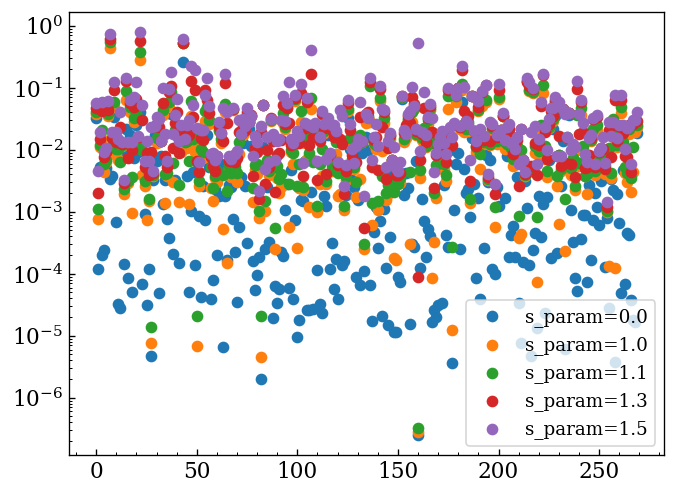

In [483]:
plt.figure()
x_list = range(270)
for s, s_param in enumerate([0, 1, 1.1, 1.3, 1.5]):
    plt.scatter(x_list, stats[s, :], label = 's_param=%.1f'%s_param)
plt.legend()
plt.yscale('log')

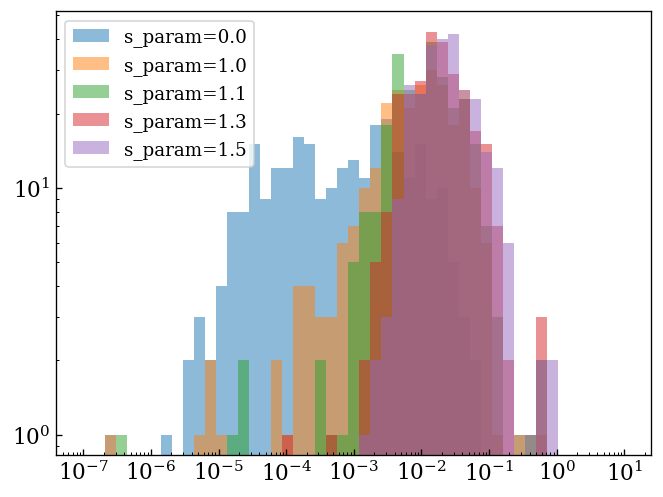

In [484]:
plt.figure()
x_list = range(270)
for s, s_param in enumerate([0, 1, 1.1, 1.3, 1.5]):
    plt.hist(stats[s, :], label = 's_param=%.1f'%s_param, alpha=0.5, bins=np.logspace(-7, 1))
plt.legend()
plt.xscale('log')
plt.yscale('log')

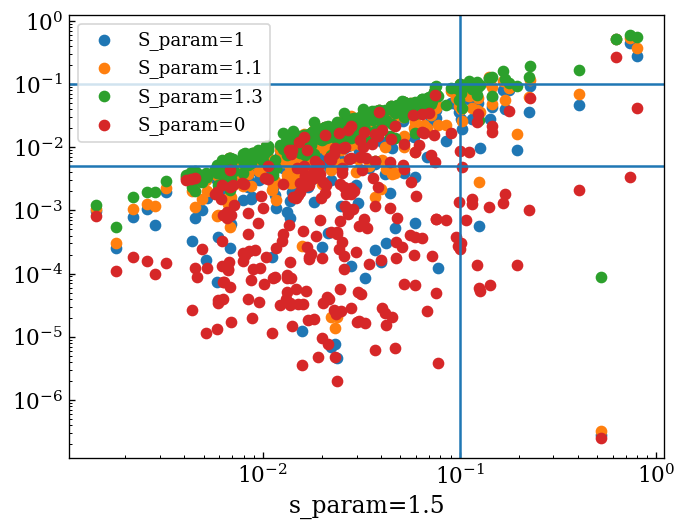

In [497]:
plt.scatter(stats[-1, :], stats[1, :], label='S_param=1')
plt.scatter(stats[-1, :], stats[2, :], label='S_param=1.1')
plt.scatter(stats[-1, :], stats[3, :], label='S_param=1.3')
plt.scatter(stats[-1, :], stats[0, :], label='S_param=0')

plt.xlabel('s_param=1.5')
plt.axhline(0.1)
plt.axvline(0.1)
plt.axhline(0.005)
plt.legend()
plt.xscale('log')
plt.yscale('log')

In [470]:
name_test ='Gaia19chh'
stats[2, :][np.asarray(names)==name_test]/stats[1, :][np.asarray(names)==name_test]

array([1.00149305])

In [615]:
np.asarray(names)[np.where(stats[-1, :]>1e-1)[0]]

array(['Gaia19cef', 'Gaia19cex', 'Gaia19cug', 'Gaia19czw', 'Gaia19czy',
       'Gaia19ews', 'Gaia20ayv', 'Gaia20cfq', 'Gaia20dff', 'Gaia20fcq',
       'Gaia21ahr', 'Gaia21cqi', 'Gaia21dck', 'Gaia21edd', 'Gaia22avg',
       'Gaia22ayd', 'Gaia22bra', 'Gaia22bxd', 'Gaia22duz', 'Gaia22dyq',
       'Gaia22eaz', 'Gaia22enp', 'Gaia23ala', 'Gaia23bef', 'Gaia23bgy',
       'Gaia23biz', 'Gaia23bsh', 'Gaia23cve'], dtype='<U9')